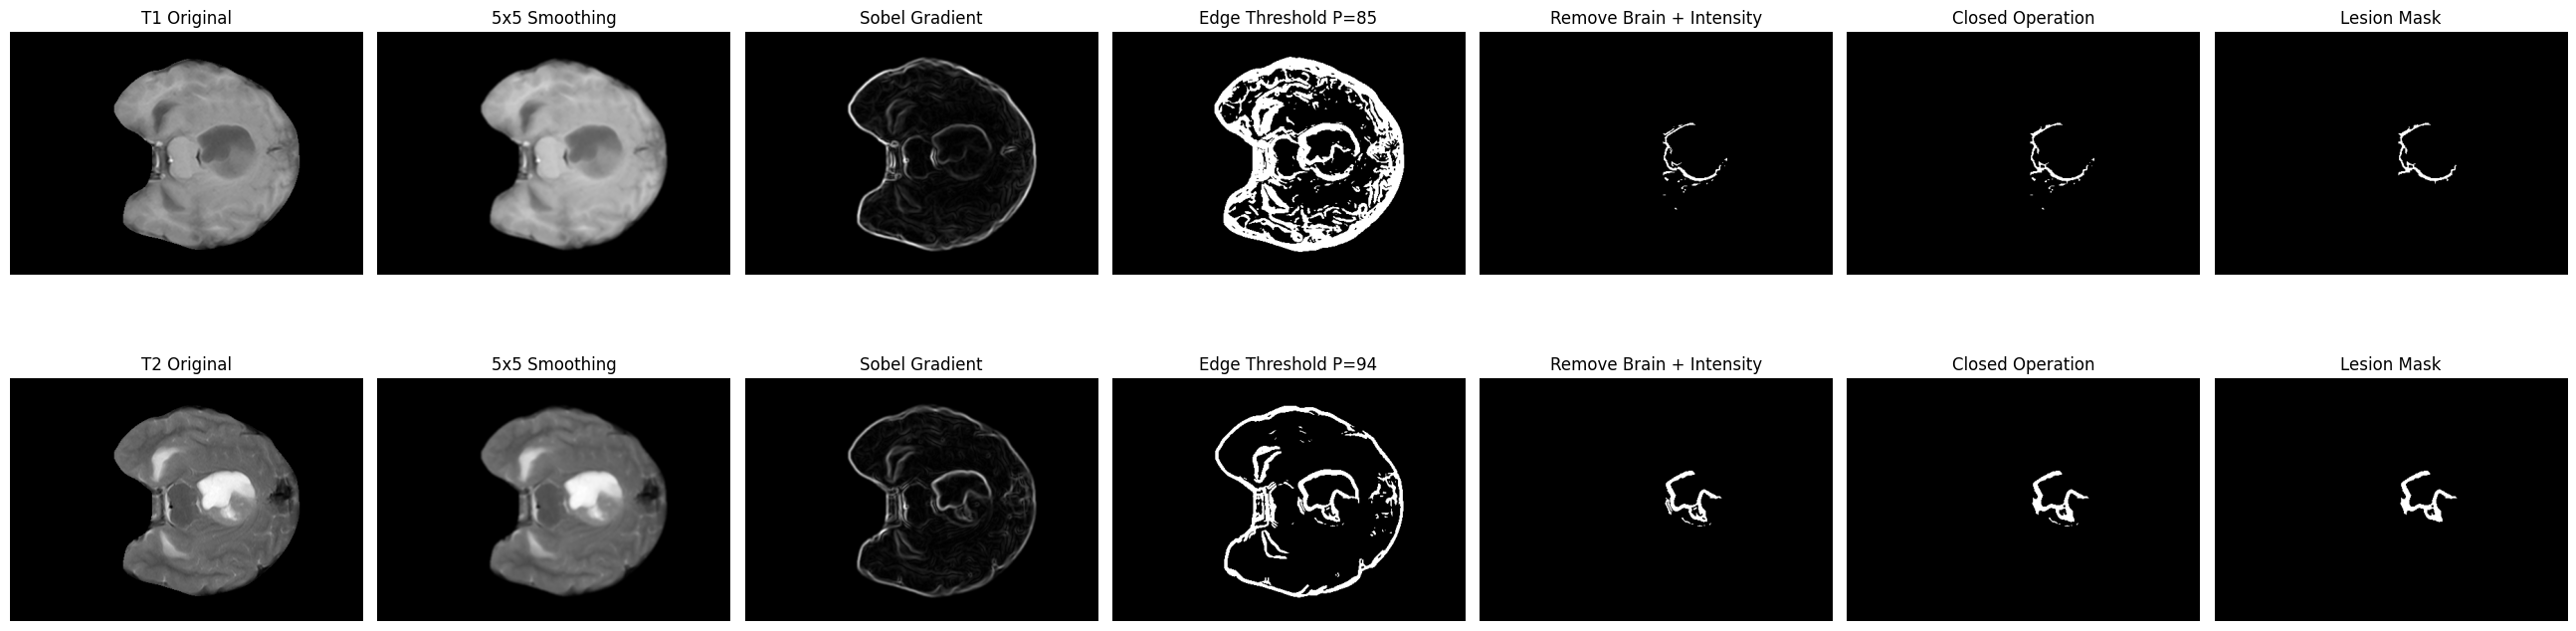

In [1]:
# ==================== Project 1: 边缘检测与病灶分割（最终版） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=8, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=3, min_size=120):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- 主 pipeline ----------
def project1_pipeline(img, percentile=97, sigma=1.5,
                      erosion_iters=15, intensity_pct=85,
                      close_size=3, min_size=120):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    return smooth, grad, raw_edge, inner_edge, closed, mask


# ==================== 可视化 ====================
config = {
    'T1': {'percentile': 85, 'intensity_pct': 85, 'min_size': 100},
    'T2': {'percentile': 94, 'intensity_pct': 88, 'min_size': 150},
}

results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img, percentile=cfg['percentile'],
                                      intensity_pct=cfg['intensity_pct'],
                                      min_size=cfg['min_size'])

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]
    pct = config[name]['percentile']

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={pct}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


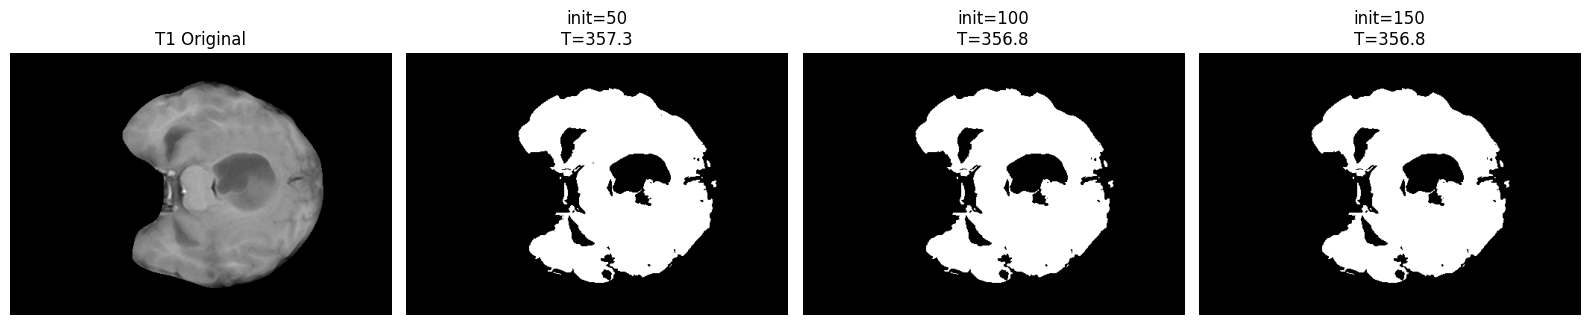

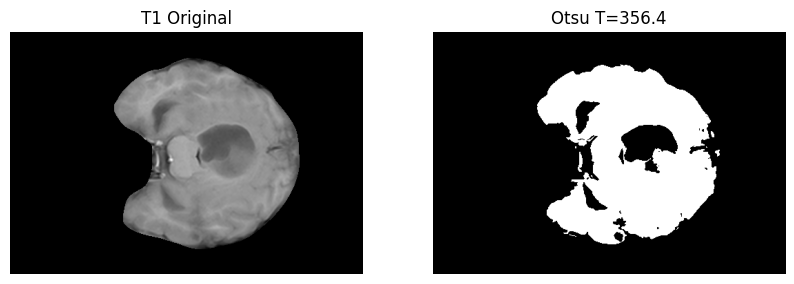

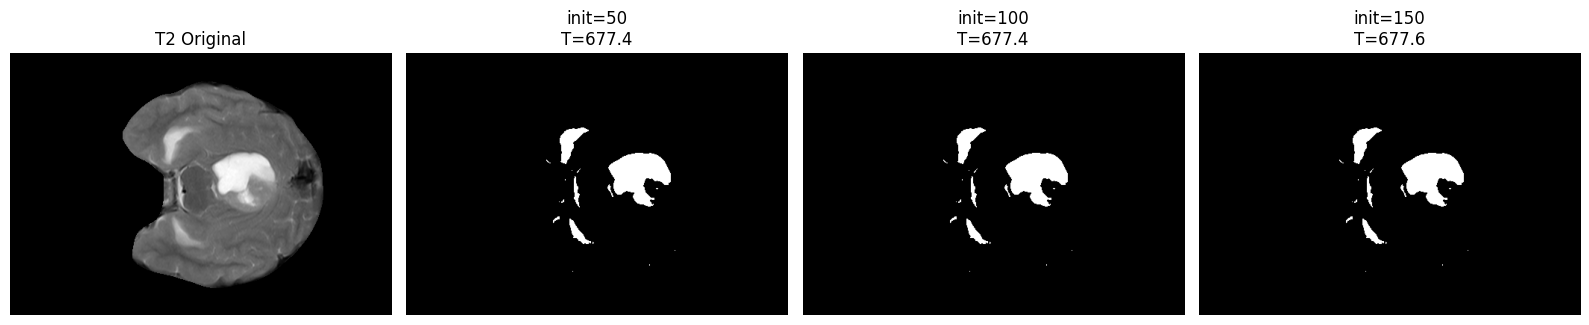

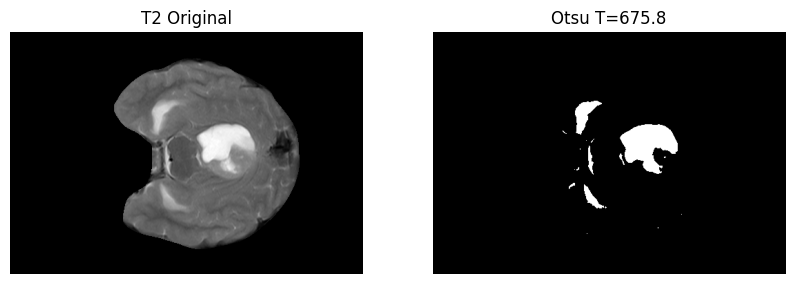

In [2]:
# ==================== Project 2: 全局阈值分割（改进版） ====================

def iterative_threshold(img, initial, mask=None):
    """迭代全局阈值，可选 mask 限定计算区域"""
    if mask is None:
        mask = np.ones_like(img, dtype=bool)
    pixels = img[mask]
    T = initial
    for _ in range(50):
        bg = pixels[pixels <= T]
        fg = pixels[pixels > T]
        if len(bg) == 0 or len(fg) == 0:
            break
        new_T = (bg.mean() + fg.mean()) / 2
        if abs(new_T - T) < 0.5:
            break
        T = new_T
    return T, (img > T) & mask

def otsu_threshold(img, mask=None):
    """Otsu 最优阈值，可选 mask 限定计算区域"""
    if mask is None:
        mask = np.ones_like(img, dtype=bool)
    pixels = img[mask]
    hist, bins = np.histogram(pixels, bins=256, range=(pixels.min(), pixels.max()))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    mean1 = np.cumsum(hist * bin_centers) / weight1
    mean2 = (np.cumsum((hist * bin_centers)[::-1]) / weight2[::-1])[::-1]
    variance12 = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:])**2
    idx = np.argmax(variance12)
    return bin_centers[idx]

# ==================== 运行 ====================
init_values = [50, 100, 150]
project2_results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    bm = brain_mask(img)  # 复用 Project 1 的脑掩码
    project2_results[name] = {}
    for init in init_values:
        T_iter, mask_iter = iterative_threshold(img, init, mask=bm)
        project2_results[name][f'iter_{init}'] = (T_iter, mask_iter)
    T_otsu = otsu_threshold(img, mask=bm)
    project2_results[name]['otsu'] = (T_otsu, (img > T_otsu) & bm)

# ==================== 可视化 ====================
for name in ['T1', 'T2']:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(eval(name), cmap='gray')
    axes[0].set_title(f'{name} Original')
    axes[0].axis('off')
    for col, init in enumerate(init_values, start=1):
        T_iter, mask_iter = project2_results[name][f'iter_{init}']
        axes[col].imshow(mask_iter, cmap='gray')
        axes[col].set_title(f'init={init}\nT={T_iter:.1f}')
        axes[col].axis('off')
    fig.tight_layout()
    plt.show()

    T_otsu, mask_otsu = project2_results[name]['otsu']
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(eval(name), cmap='gray')
    ax[0].set_title(f'{name} Original')
    ax[0].axis('off')
    ax[1].imshow(mask_otsu, cmap='gray')
    ax[1].set_title(f'Otsu T={T_otsu:.1f}')
    ax[1].axis('off')
    plt.show()


K=2, spatial_weight=0.000 -> area=52213 mm^2
K=2, spatial_weight=0.010 -> area=52213 mm^2
K=2, spatial_weight=0.030 -> area=52213 mm^2
K=2, spatial_weight=0.050 -> area=52213 mm^2
K=2, spatial_weight=0.100 -> area=52213 mm^2
K=3, spatial_weight=0.000 -> area=4999 mm^2
K=3, spatial_weight=0.010 -> area=4999 mm^2
K=3, spatial_weight=0.030 -> area=4999 mm^2
K=3, spatial_weight=0.050 -> area=52176 mm^2
K=3, spatial_weight=0.100 -> area=52181 mm^2
K=4, spatial_weight=0.000 -> area=4706 mm^2
K=4, spatial_weight=0.010 -> area=4746 mm^2
K=4, spatial_weight=0.030 -> area=4999 mm^2
K=4, spatial_weight=0.050 -> area=52176 mm^2
K=4, spatial_weight=0.100 -> area=52178 mm^2
K=5, spatial_weight=0.000 -> area=4509 mm^2
K=5, spatial_weight=0.010 -> area=4732 mm^2
K=5, spatial_weight=0.030 -> area=4999 mm^2
K=5, spatial_weight=0.050 -> area=4999 mm^2
K=5, spatial_weight=0.100 -> area=4999 mm^2

===== Lesion Area Summary =====
Region Growing:          2595 mm^2
Watershed:               3029 mm^2
K-means 

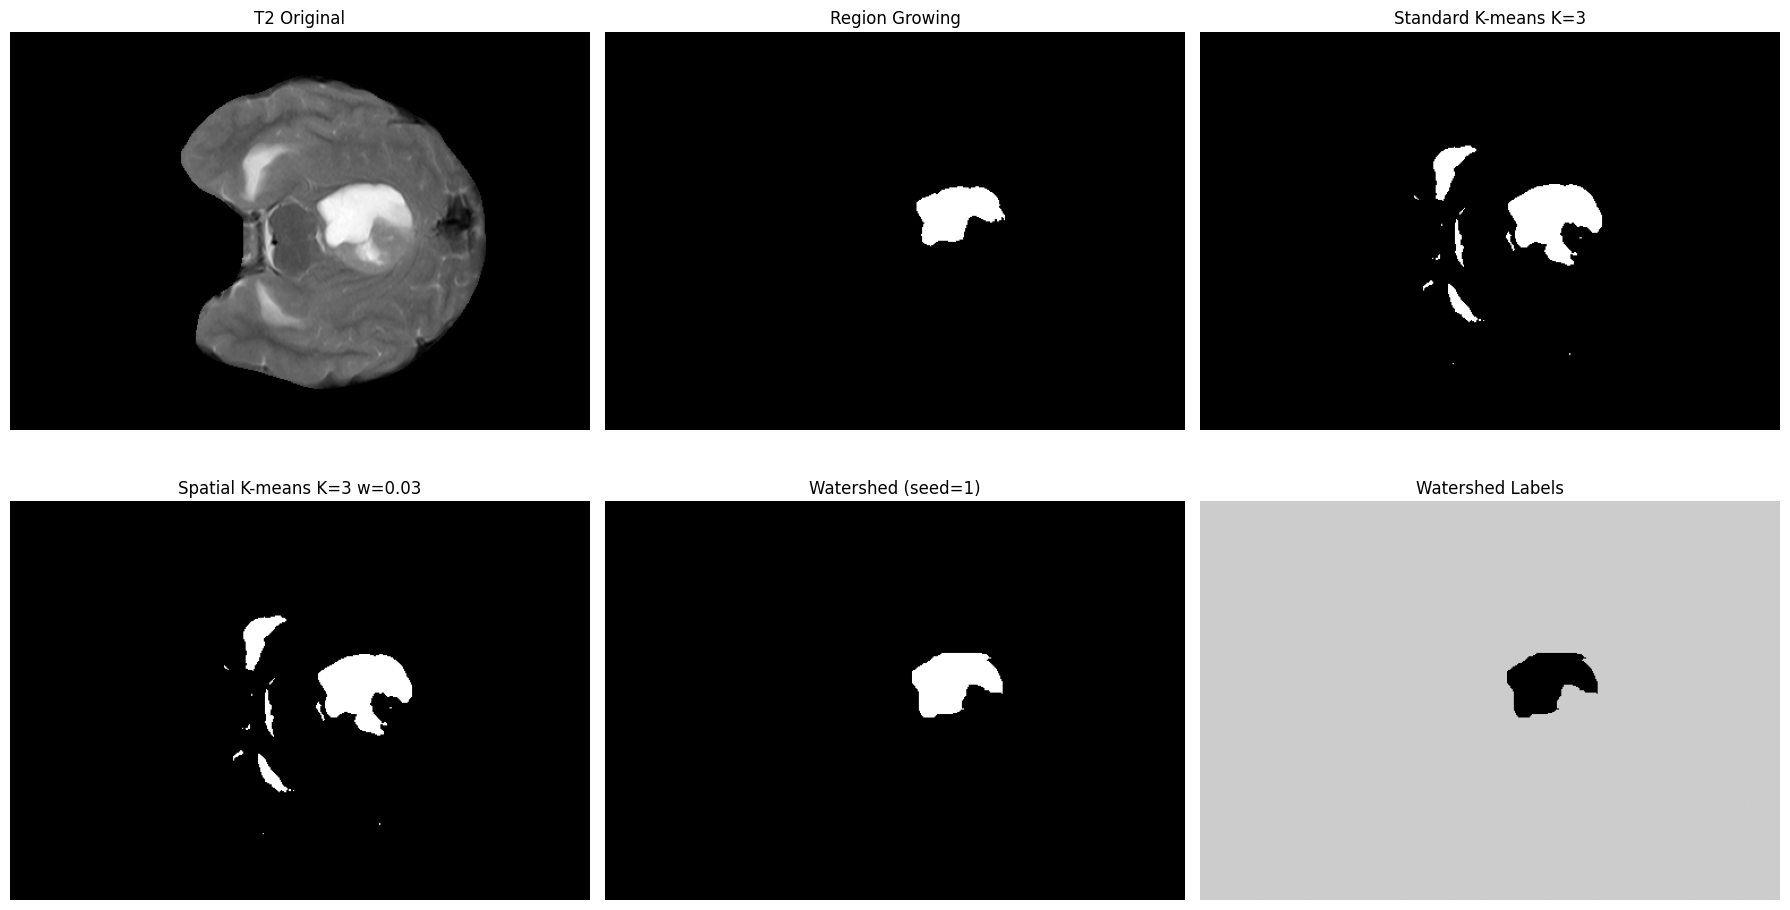

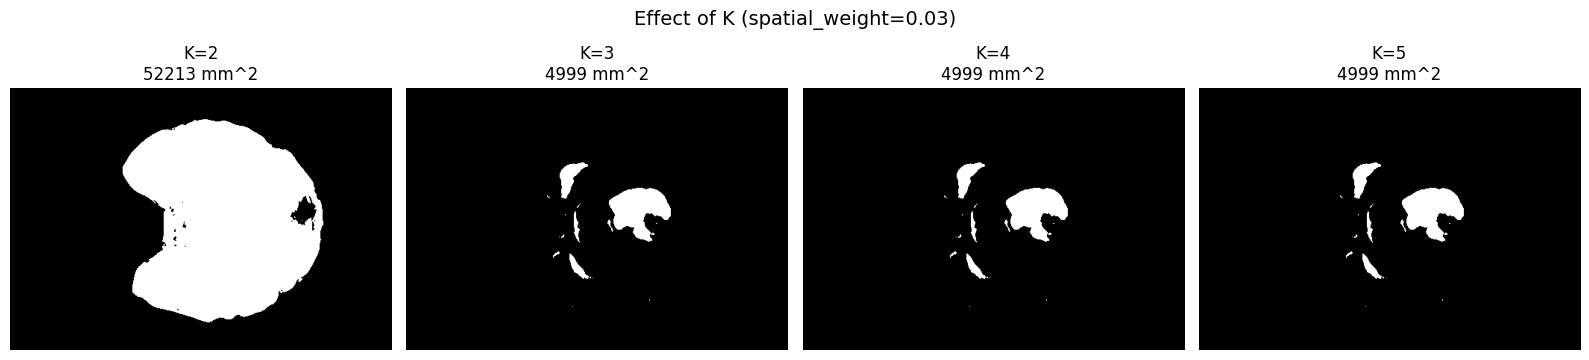

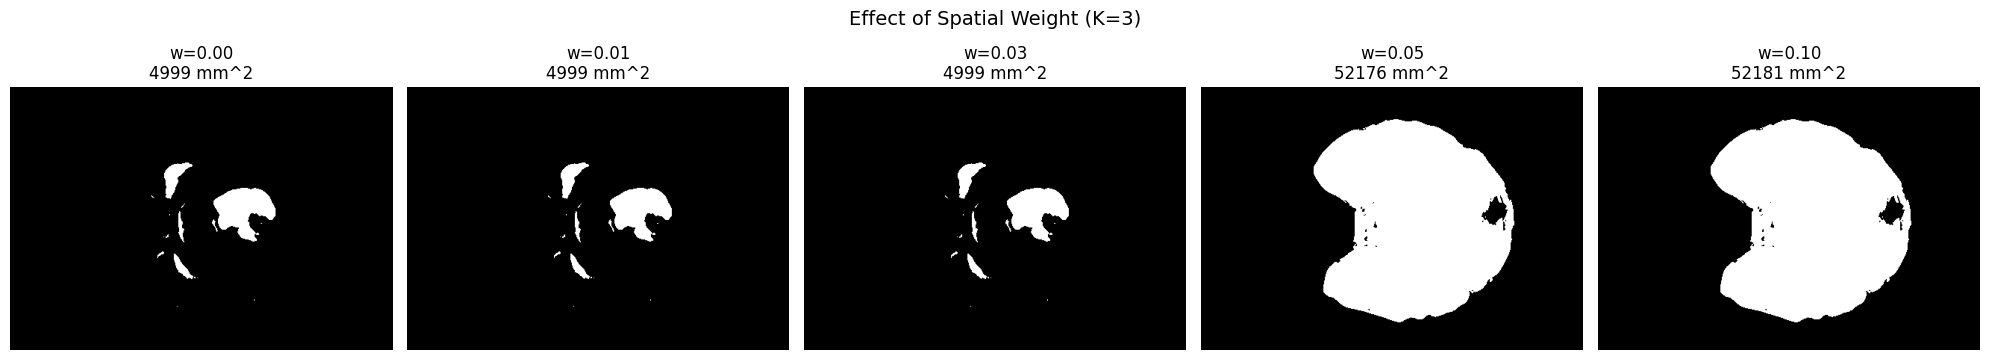

In [5]:
# ==================== Project 3: T2 分割与体积计算（完整版） ====================

def region_growing(img, seed, thresh):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = img[seed]
    while stack:
        y, x = stack.pop()
        if mask[y, x]:
            continue
        if abs(float(img[y, x]) - float(seed_val)) <= thresh:
            mask[y, x] = True
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                        stack.append((ny, nx))
    return mask

def kmeans(img, K=3, spatial_weight=0.0, iterations=20):
    h, w = img.shape
    coords_y, coords_x = np.indices(img.shape)
    features = np.stack([img.ravel(),
                         coords_y.ravel() * spatial_weight,
                         coords_x.ravel() * spatial_weight], axis=1)
    rng = np.random.default_rng(123)
    centers = features[rng.choice(features.shape[0], size=K, replace=False)]
    labels = np.zeros(features.shape[0], dtype=int)
    for _ in range(iterations):
        d = np.linalg.norm(features[:, None] - centers[None, :], axis=2)
        labels = np.argmin(d, axis=1)
        for k in range(K):
            members = features[labels == k]
            if len(members):
                centers[k] = members.mean(axis=0)
    return labels.reshape(h, w), centers

def lesion_area(mask):
    return mask.sum() * 1.0  # 1mm x 1mm resolution

# ==================== 1. Region Growing ====================
seed = np.unravel_index(np.argmax(T2), T2.shape)
region_mask = region_growing(T2, seed, thresh=230)

# ==================== 2. Improved K-means: test K and spatial_weight ====================
K_values = [2, 3, 4, 5]
weight_values = [0.0, 0.01, 0.03, 0.05, 0.1]

kmeans_results = {}
for K in K_values:
    for w in weight_values:
        labels, centers = kmeans(T2, K=K, spatial_weight=w)
        intensity_order = np.argsort(centers[:, 0])
        lesion_cluster = intensity_order[-1]
        mask = labels == lesion_cluster
        kmeans_results[(K, w)] = (mask, labels, centers)
        area = lesion_area(mask)
        print(f'K={K}, spatial_weight={w:.3f} -> area={area:.0f} mm^2')

# -------- 3. Watershed (原始梯度版) --------
smooth_T2 = preprocess(T2, sigma=2.0)
grad_T2, _, _ = sobel_gradients(smooth_T2)

# 原始梯度归一化到 [0, 255]: 边界(高梯度) → 高代价 → 屏障
#                          均匀区(低梯度) → 低代价 → 水流容易穿过
grad_int = (grad_T2 / grad_T2.max() * 255).astype(np.uint16)

# 病灶种子: T2 最亮像素
seed = np.unravel_index(np.argmax(T2), T2.shape)

# 背景种子: 脑掩码外的所有区域
bm = brain_mask(T2)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1
markers[~bm] = 2

watershed_label = ndi.watershed_ift(grad_int, markers)
watershed_mask = watershed_label == 1

# ==================== 4. Standard vs Spatial-weighted K-means ====================
compare_weights = [0.0, 0.01, 0.03, 0.05, 0.1]
compare_masks = {}
for w in compare_weights:
    labels, centers = kmeans(T2, K=3, spatial_weight=w)
    lesion_cluster = np.argmax(centers[:, 0])
    compare_masks[w] = labels == lesion_cluster

# ==================== 5. Summary ====================
print('\n===== Lesion Area Summary =====')
print(f'Region Growing:          {lesion_area(region_mask):.0f} mm^2')
print(f'Watershed:               {lesion_area(watershed_mask):.0f} mm^2')
for w in compare_weights:
    print(f'K-means K=3 w={w:.2f}:       {lesion_area(compare_masks[w]):.0f} mm^2')

# ==================== Visualization ====================
# -- Figure 1: Four methods overview (2x3) --
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].set_title('T2 Original')
axes[0, 1].imshow(region_mask, cmap='gray')
axes[0, 1].set_title('Region Growing')
km_std_mask, _, _ = kmeans_results[(3, 0.0)]
axes[0, 2].imshow(km_std_mask, cmap='gray')
axes[0, 2].set_title('Standard K-means K=3')
km_sp_mask, _, _ = kmeans_results[(3, 0.03)]
axes[1, 0].imshow(km_sp_mask, cmap='gray')
axes[1, 0].set_title('Spatial K-means K=3 w=0.03')
axes[1, 1].imshow(watershed_mask, cmap='gray')
axes[1, 1].set_title('Watershed (seed=1)')
axes[1, 2].imshow(watershed_label, cmap='nipy_spectral')
axes[1, 2].set_title('Watershed Labels')
for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

# -- Figure 2: Effect of K (spatial_weight=0.03) --
fig, axes = plt.subplots(1, len(K_values), figsize=(4*len(K_values), 4))
for i, K in enumerate(K_values):
    mask, _, _ = kmeans_results[(K, 0.03)]
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'K={K}\n{lesion_area(mask):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of K (spatial_weight=0.03)', fontsize=14)
fig.tight_layout()
plt.show()

# -- Figure 3: Effect of spatial_weight (K=3) --
fig, axes = plt.subplots(1, len(compare_weights), figsize=(4*len(compare_weights), 4))
for i, w in enumerate(compare_weights):
    axes[i].imshow(compare_masks[w], cmap='gray')
    axes[i].set_title(f'w={w:.2f}\n{lesion_area(compare_masks[w]):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of Spatial Weight (K=3)', fontsize=14)
fig.tight_layout()
plt.show()
